# MP3


In [9]:
# for tpu support.
# !pip install torch_xla[tpu]

In [6]:
import torch

try:
    import torch_xla
    import torch_xla.core.xla_model as xm
    DEVICE = torch_xla.device()
    DEVICE_TYPE = 'tpu'
except ImportError:
    if torch.cuda.is_available():
        DEVICE = torch.device('cuda')
        DEVICE_TYPE = 'cuda'
    else:
        DEVICE = torch.device('cpu')
        DEVICE_TYPE = 'cpu'

if DEVICE_TYPE == 'tpu':
    dtype = 'bfloat16'
elif DEVICE_TYPE == 'cuda' and torch.cuda.is_bf16_supported():
    dtype = 'bfloat16'
elif DEVICE_TYPE == 'cuda':
    dtype = 'float16'
else:
    dtype = 'float32'   

ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]

print(f'DEVICE: {DEVICE_TYPE} - {DEVICE}')

DEVICE: cuda - cuda


---

### 1. Character-Level LSTM.

This network is based off of Andrej Karpathy's [blog on RNNs](http://karpathy.github.io/2015/05/21/rnn-effectiveness/). 

In [7]:
import requests
import os

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

#### Load in Data

In [8]:
full_shakespeare_file_path = 'data/shakespeare_char/input.txt'
if not os.path.exists(full_shakespeare_file_path):
    data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'
    os.makedirs(os.path.dirname(full_shakespeare_file_path), exist_ok=True)
    with open(full_shakespeare_file_path, 'w', encoding='utf-8') as f:
        f.write(requests.get(data_url).text)

sonnet_file_path = 'data/shakespeare_sonnet/input.txt'
if not os.path.exists(sonnet_file_path):
    data_url = 'https://caltech-cs155.s3.us-east-2.amazonaws.com/miniprojects/project3/data/shakespeare.txt'
    os.makedirs(os.path.dirname(sonnet_file_path), exist_ok=True)
    with open(sonnet_file_path, 'w', encoding='utf-8') as f:
        f.write(requests.get(data_url).text)

In [9]:
import re

with open(full_shakespeare_file_path, 'r', encoding='utf-8') as f:
    text = f.read()

with open(sonnet_file_path, 'r', encoding='utf-8') as f:
    sonnet_text_raw = f.read()

SONNET_START = '@'
sonnet_text_raw = re.sub(r'^ *\d+\n', SONNET_START + '\n', sonnet_text_raw, flags=re.MULTILINE)
print(sonnet_text_raw[:200])

@
From fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou contracted to thine ow


#### Tokenization.

In [50]:
chars = tuple(sorted(set(text) | set(sonnet_text_raw)))
itos = dict(enumerate(chars))
stoi = {ch: ii for ii, ch in itos.items()}
vocab_size = len(chars)

encoded = np.array([stoi[ch] for ch in text])

n = len(encoded)
split_idx = int(n * 0.9)
train_data = encoded[:split_idx]
val_data = encoded[split_idx:]

print(f"Dataset size:  {len(text):,} charas")
print(f"Sonnet size:   {len(sonnet_text_raw):,} chars")
print(f"Vocab size:    {vocab_size} (combined plays + sonnets)")
print(f"Train:         {len(train_data):,} tokens ({len(train_data)/n:.0%})")
print(f"Val:           {len(val_data):,} tokens ({len(val_data)/n:.0%})")
print(f"Characters:    {repr(''.join(chars))}")

Dataset size:  1,115,393 charas
Sonnet size:   94,903 chars
Vocab size:    68 (combined plays + sonnets)
Train:         1,003,853 tokens (90%)
Val:           111,540 tokens (10%)
Characters:    "\n !$&'(),-.3:;?@ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"


#### Batching

In [51]:
def get_batches(arr, batch_size, seq_length):
    batch_size_total = batch_size * seq_length
    n_batches = len(arr)//batch_size_total

    arr = arr[:n_batches * batch_size_total]
    arr = arr.reshape((batch_size, -1))

    for n in range(0, arr.shape[1], seq_length):
        x = arr[:, n:n+seq_length]
        y = np.zeros_like(x)
        try:
            y[:, :-1], y[:, -1] = x[:, 1:], arr[:, n+seq_length]
        except IndexError:
            y[:, :-1], y[:, -1] = x[:, 1:], arr[:, 0]
        yield x, y

#### Model

In [52]:
class CharLSTM(nn.Module):

    def __init__(self, tokens, n_hidden=256, n_layers=2,
                               drop_prob=0.5, lr=0.001):
        super().__init__()
        self.drop_prob = drop_prob
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.lr = lr

        self.chars = tokens
        self.itos = dict(enumerate(self.chars))
        self.stoi = {ch: ii for ii, ch in self.itos.items()}

        self.lstm = nn.LSTM(len(self.chars), n_hidden, n_layers,
                            dropout=drop_prob, batch_first=True)

        self.dropout = nn.Dropout(drop_prob)
        self.fc = nn.Linear(n_hidden, len(self.chars))


    def forward(self, x, hidden):
        r_output, hidden = self.lstm(x, hidden)
        out = self.dropout(r_output)
        out = out.contiguous().view(-1, self.n_hidden)
        out = self.fc(out)

        return out, hidden


    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        hidden = (weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(DEVICE),
                  weight.new(self.n_layers, batch_size, self.n_hidden).zero_().to(DEVICE))
        return hidden


#### train fn


In [ ]:
import time

def train(model, train_data, val_data, save_path, epochs=10, batch_size=10, seq_length=50, lr=0.001, clip=5, print_every=10):
    model.to(DEVICE)
    model.train()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    n_chars = len(model.chars)

    counter = 0
    best_val_loss = float('inf')
    train_loss_history, val_loss_history, steps = [], [], []
    t0 = time.time()

    for e in range(epochs):
        h = model.init_hidden(batch_size)

        for x, y in get_batches(train_data, batch_size, seq_length):
            counter += 1
            inputs = F.one_hot(torch.tensor(x), num_classes=n_chars).float().to(DEVICE)
            targets = torch.tensor(y, dtype=torch.long, device=DEVICE).view(-1)
            h = tuple(each.data for each in h)

            optimizer.zero_grad()
            output, h = model(inputs, h)
            loss = criterion(output, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            if DEVICE_TYPE == 'tpu':
              xm.optimizer_step(optimizer)
            else: 
              optimizer.step()

            if counter % print_every == 0:
                model.eval()
                val_h = model.init_hidden(batch_size)
                val_losses = []
                with torch.no_grad():
                    for vx, vy in get_batches(val_data, batch_size, seq_length):
                        vinputs = F.one_hot(torch.tensor(vx), num_classes=n_chars).float().to(DEVICE)
                        vtargets = torch.tensor(vy, dtype=torch.long, device=DEVICE).view(-1)
                        val_h = tuple(each.data for each in val_h)
                        vout, val_h = model(vinputs, val_h)
                        val_losses.append(criterion(vout, vtargets).item())
                model.train()

                avg_val = np.mean(val_losses)
                train_loss_history.append(loss.item())
                val_loss_history.append(avg_val)
                steps.append(counter)

                marker = ""
                if avg_val < best_val_loss:
                    best_val_loss = avg_val
                    torch.save({
                        'model_state': model.state_dict(),
                        'optimizer_state': optimizer.state_dict(),
                        'chars': model.chars,
                        'n_hidden': model.n_hidden,
                        'n_layers': model.n_layers,
                        'best_val_loss': best_val_loss,
                        'epoch': e,
                        'step': counter,
                    }, save_path)
                    marker = " *"

                elapsed = time.time() - t0
                print(f"Epoch {e+1}/{epochs} | Step {counter} | "
                      f"train {loss.item():.4f} | val {avg_val:.4f} | "
                      f"{elapsed:.1f}s{marker}")
                t0 = time.time()

    print(f"\nDone. Best val loss: {best_val_loss:.4f} — saved to {save_path}")
    return steps, train_loss_history, val_loss_history

#### Instantiate the model

In [54]:
batch_size = 128
seq_length = 100
n_epochs = 20
lr = 0.001
clip=5
print_every=10

BEST_LSTM_PATH = 'out/best_lstm.pt'

In [55]:
n_hidden=512
n_layers=3

model = CharLSTM(chars, n_hidden, n_layers)
print(model)

print(f"Parameters: {sum(p.numel() for p in model.parameters())}")

CharLSTM(
  (lstm): LSTM(68, 512, num_layers=3, batch_first=True, dropout=0.5)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=68, bias=True)
)
Parameters: 5429316


In [56]:
steps, train_loss_history, val_loss_history = train(
    model, train_data, val_data,
    save_path=BEST_LSTM_PATH,
    epochs=n_epochs, batch_size=batch_size,
    seq_length=seq_length, lr=lr, clip=clip,
    print_every=print_every,
)

Epoch 1/20 | Step 10 | train 3.4039 | val 3.3713 | 0.7s *
Epoch 1/20 | Step 20 | train 3.3175 | val 3.3548 | 0.7s *
Epoch 1/20 | Step 30 | train 3.3431 | val 3.8594 | 0.5s
Epoch 1/20 | Step 40 | train 3.3648 | val 3.3516 | 0.6s *
Epoch 1/20 | Step 50 | train 3.3441 | val 3.3509 | 0.7s *
Epoch 1/20 | Step 60 | train 3.3373 | val 3.3488 | 0.7s *
Epoch 1/20 | Step 70 | train 3.3092 | val 3.3433 | 0.7s *
Epoch 2/20 | Step 80 | train 3.3263 | val 3.3438 | 0.5s
Epoch 2/20 | Step 90 | train 3.3205 | val 3.3426 | 0.6s *
Epoch 2/20 | Step 100 | train 3.3221 | val 3.3436 | 0.5s
Epoch 2/20 | Step 110 | train 3.3332 | val 3.3417 | 0.6s *
Epoch 2/20 | Step 120 | train 3.3235 | val 3.3391 | 0.7s *
Epoch 2/20 | Step 130 | train 3.3037 | val 3.3375 | 0.7s *
Epoch 2/20 | Step 140 | train 3.3063 | val 3.3428 | 0.5s
Epoch 2/20 | Step 150 | train 3.3041 | val 3.3322 | 0.6s *
Epoch 3/20 | Step 160 | train 3.2671 | val 3.3220 | 0.7s *
Epoch 3/20 | Step 170 | train 3.2515 | val 3.2868 | 0.7s *
Epoch 3/20 | S

#### Train vs Val Loss

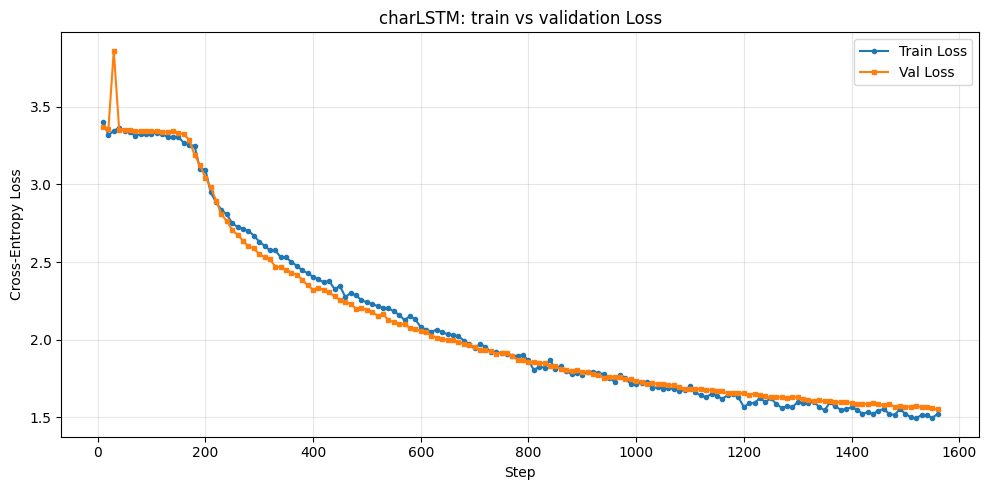

In [58]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss_history, label='Train Loss', marker='o', markersize=3)
plt.plot(steps, val_loss_history, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('charLSTM: train vs validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### making predictions


In [61]:
def predict(model, char, h=None, top_k=None):
        x = torch.tensor([[model.stoi[char]]])
        inputs = F.one_hot(x, num_classes=len(model.chars)).float().to(DEVICE)

        h = tuple([each.data for each in h])
        out, h = model(inputs, h)

        p = F.softmax(out, dim=1).data.cpu()

        if top_k is None:
            top_ch = np.arange(len(model.chars))
        else:
            p, top_ch = p.topk(top_k)
            top_ch = top_ch.numpy().squeeze()

        p = p.numpy().squeeze()
        char = np.random.choice(top_ch, p=p/p.sum())

        return model.itos[char], h

#### priming and generating text

In [62]:
def sample(model, size, prime='The', top_k=None):
    model.to(DEVICE)
    model.eval()

    chars = [ch for ch in prime]
    h = model.init_hidden(1)
    for ch in prime:
        char, h = predict(model, ch, h, top_k=top_k)

    chars.append(char)

    for ii in range(size):
        char, h = predict(model, chars[-1], h, top_k=top_k)
        chars.append(char)

    return ''.join(chars)

#### Fine-tune LSTM on Shakespeare Sonnets


In [63]:
sonnet_encoded = np.array([stoi[ch] for ch in sonnet_text_raw])
sn = len(sonnet_encoded)
sonnet_split = int(sn * 0.9)
sonnet_train = sonnet_encoded[:sonnet_split]
sonnet_val = sonnet_encoded[sonnet_split:]

print(f"Sonnet dataset: {len(sonnet_text_raw):,} characters")
print(f"Vocab size:   {vocab_size} (same combined vocab)")
print(f"Train: {len(sonnet_train):,} tokens | Val: {len(sonnet_val):,} tokens")

Sonnet dataset: 94,903 characters
Vocab size:   68 (same combined vocab)
Train: 85,412 tokens | Val: 9,491 tokens


In [64]:
checkpoint = torch.load(BEST_LSTM_PATH, map_location=DEVICE, weights_only=False)
print(f"Loaded best checkpoint — val loss {checkpoint['best_val_loss']:.4f} "
      f"(epoch {checkpoint['epoch']+1}, step {checkpoint['step']})")

ft_model = CharLSTM(chars,
                  n_hidden=checkpoint['n_hidden'],
                  n_layers=checkpoint['n_layers'])
ft_model.load_state_dict(checkpoint['model_state'])
ft_model.to(DEVICE)

print(f"Fine-tune model: {sum(p.numel() for p in ft_model.parameters()):,} parameters")

Loaded best checkpoint — val loss 1.5516 (epoch 20, step 1560)
Fine-tune model: 5,429,316 parameters


In [ ]:
steps, train_data_losses, val_data_losses = train(
    ft_model, sonnet_train, sonnet_val,
    save_path='out/best_lstm_sonnet.pt',
    epochs=10, batch_size=64,
    seq_length=100, lr=3e-4, print_every=5,
)

Epoch 1/10 | Step 5 | train 1.6790 | val 1.6539 | 0.4s *
Epoch 1/10 | Step 10 | train 1.6608 | val 1.6246 | 0.4s *
Epoch 2/10 | Step 15 | train 1.6334 | val 1.6068 | 0.4s *
Epoch 2/10 | Step 20 | train 1.6120 | val 1.5957 | 0.4s *
Epoch 2/10 | Step 25 | train 1.5848 | val 1.5847 | 0.4s *
Epoch 3/10 | Step 30 | train 1.5780 | val 1.5762 | 0.4s *
Epoch 3/10 | Step 35 | train 1.5858 | val 1.5702 | 0.4s *
Epoch 4/10 | Step 40 | train 1.5879 | val 1.5641 | 0.4s *
Epoch 4/10 | Step 45 | train 1.5695 | val 1.5605 | 0.4s *
Epoch 4/10 | Step 50 | train 1.5754 | val 1.5569 | 0.4s *
Epoch 5/10 | Step 55 | train 1.5271 | val 1.5529 | 0.4s *
Epoch 5/10 | Step 60 | train 1.5208 | val 1.5510 | 0.4s *
Epoch 5/10 | Step 65 | train 1.5816 | val 1.5497 | 0.4s *
Epoch 6/10 | Step 70 | train 1.5147 | val 1.5469 | 0.4s *
Epoch 6/10 | Step 75 | train 1.5208 | val 1.5442 | 0.4s *
Epoch 7/10 | Step 80 | train 1.5351 | val 1.5411 | 0.4s *
Epoch 7/10 | Step 85 | train 1.5249 | val 1.5414 | 0.2s
Epoch 7/10 | Step

#### Fine-tuning Loss Curve (Sonnets)

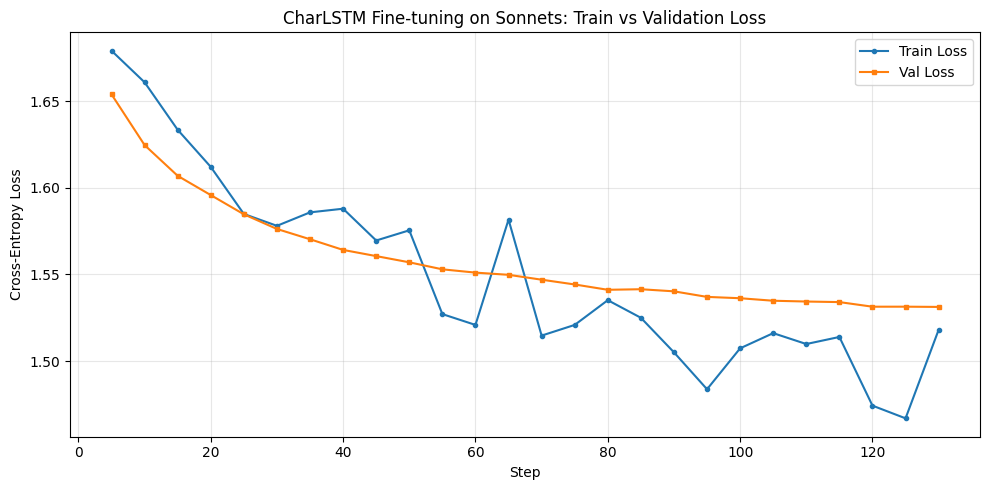

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 5))
plt.plot(steps, train_data_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(steps, val_data_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('CharLSTM Fine-tuning on Sonnets: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Sample Sonnets from Fine-tuned LSTM

In [75]:
print(sample(ft_model, 500, prime='@\nShall I compare thee', top_k=5))

@
Shall I compare thee, my love of might,
And meant and but sunden self though beauty
By that thou art true with seem and thy still,
Since that I will be as my france with strive,
So with a tearing arile was the steel.
The life's point will banish'd only such sees,
Thy sing the best being show in thy brain thee,
What I take thy pale agion thy blow without a straight,
Thine treasure of temble of him their seas,
When thou thou would the pations of my body
To him so thy seas of these thought of thy love,
To that that str


---

### 2. nanoGPT

now training a standard Transformer GPT (as per [Karpathy's nanoGPT](https://github.com/karpathy/nanoGPT)) on the same Shakespeare character-level dataset.

In [28]:
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

import os
import math
import time
import inspect
from dataclasses import dataclass
from contextlib import nullcontext


In [29]:
@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50304
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = True

In [30]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                     .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

In [31]:
class NanoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.token_emb = nn.Embedding(config.vocab_size, config.n_embd)
        self.pos_emb = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([TransformerBlock(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd, bias=config.bias)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.token_emb.weight = self.lm_head.weight  # weight tying
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.size()
        assert t <= self.config.block_size
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.drop(self.token_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

    def get_num_params(self):
        return sum(p.numel() for p in self.parameters())

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, fused=use_fused)
        return optimizer

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

#### Tokenization

In [32]:
import numpy as np
import torch

import sentencepiece as spm

SP_PREFIX = 'out/sp_shakespeare'
SP_VOCAB_SIZE = 1024

spm.SentencePieceTrainer.train(
    input='data/shakespeare_char/input.txt',
    model_prefix=SP_PREFIX,
    vocab_size=SP_VOCAB_SIZE,
    model_type='bpe',
    character_coverage=1.0,
    pad_id=3,
)

sp = spm.SentencePieceProcessor(model_file=f'{SP_PREFIX}.model')
vocab_size = sp.get_piece_size()

encode = lambda s: sp.encode(s)
decode = lambda ids: sp.decode(ids)

encoded = np.array(encode(text), dtype=np.int64)

n = len(encoded)
train_data = encoded[:int(n * 0.9)]
val_data = encoded[int(n * 0.9):]

print(f"BPE vocab size: {vocab_size}")
print(f"Text: {len(text):,} chars - {n:,} tokens ({len(text)/n:.1f} chars/token)")
print(f"Train: {len(train_data):,} tokens | Val: {len(val_data):,} tokens")

BPE vocab size: 1024
Text: 1,115,393 chars - 401,271 tokens (2.8 chars/token)
Train: 361,143 tokens | Val: 40,128 tokens


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/shakespeare_char/input.txt
  input_format: 
  model_prefix: out/sp_shakespeare
  model_type: BPE
  vocab_size: 1024
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: 3
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential

#### Build model and data loader

In [33]:
block_size = 256
batch_size = 64

BEST_GPT_PATH = 'out/best_nanogpt.pt'

config = GPTConfig(
    block_size=block_size,
    vocab_size=vocab_size,
    n_layer=6,
    n_head=6,
    n_embd=384,
    dropout=0.2,
    bias=False,
)

model = NanoGPT(config).to(DEVICE)
print(f"nanoGPT model: {model.get_num_params():,} parameters")

def gpt_get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].copy()) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].copy()) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

nanoGPT model: 11,113,344 parameters


In [34]:
learning_rate = 1e-3
max_iters = 5000
warmup_iters = 200
lr_decay_iters = 5000
min_lr = 1e-4
eval_interval = 500
eval_iters = 200
grad_clip = 1.0
log_interval = 100

ctx = torch.amp.autocast(device_type='cuda', dtype=ptdtype) if DEVICE_TYPE == 'cuda' else nullcontext()

scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE_TYPE == 'cuda' and dtype == 'float16'))

/tmp/ipykernel_1384723/607683888.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE_TYPE == 'cuda' and dtype == 'float16'))


#### Training loop

In [35]:
optimizer = model.configure_optimizers(
    weight_decay=1e-1,
    learning_rate=learning_rate,
    betas=(0.9, 0.99),
    device_type=DEVICE_TYPE,
)

def get_lr(it):
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    if it > lr_decay_iters:
        return min_lr
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = gpt_get_batch(split)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [36]:
torch.manual_seed(1337)

train_losses = []
val_losses = []
eval_steps = []
best_val_loss = 1e9

model.train()
t0 = time.time()

for iter_num in range(max_iters + 1):
    lr = get_lr(iter_num)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    if iter_num % eval_interval == 0:
        losses = estimate_loss()
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        eval_steps.append(iter_num)
        marker = ""
        if losses['val'] < best_val_loss:
            best_val_loss = losses['val']
            torch.save({
                'model_state': model.state_dict(),
                'config': config,
                'best_val_loss': best_val_loss,
                'iter_num': iter_num,
            }, BEST_GPT_PATH)
            marker = " *"
        print(f"step {iter_num:5d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f} | lr {lr:.2e}{marker}")

    X, Y = gpt_get_batch('train')
    with ctx:
        _, loss = model(X, Y)

    scaler.scale(loss).backward()
    if grad_clip != 0.0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    scaler.step(optimizer)
    scaler.update()
    optimizer.zero_grad(set_to_none=True)

    if iter_num % log_interval == 0 and iter_num > 0 and iter_num % eval_interval != 0:
        dt = time.time() - t0
        print(f"step {iter_num:5d} | loss {loss.item():.4f} | time {dt*1000:.0f}ms")
    t0 = time.time()

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

step     0 | train loss 7.0361 | val loss 7.0339 | lr 0.00e+00 *
step   100 | loss 5.0270 | time 69ms
step   200 | loss 4.2445 | time 69ms
step   300 | loss 3.9977 | time 69ms
step   400 | loss 3.7673 | time 69ms
step   500 | train loss 3.3808 | val loss 4.1623 | lr 9.91e-04 *
step   600 | loss 3.3535 | time 69ms
step   700 | loss 3.1983 | time 69ms
step   800 | loss 2.9385 | time 69ms
step   900 | loss 2.7257 | time 69ms
step  1000 | train loss 2.1127 | val loss 4.4276 | lr 9.40e-04
step  1100 | loss 2.4689 | time 69ms
step  1200 | loss 2.2980 | time 69ms
step  1300 | loss 2.1211 | time 69ms
step  1400 | loss 2.0112 | time 69ms
step  1500 | train loss 1.1078 | val loss 5.0960 | lr 8.47e-04
step  1600 | loss 1.6810 | time 69ms
step  1700 | loss 1.6133 | time 69ms
step  1800 | loss 1.5524 | time 69ms
step  1900 | loss 1.4633 | time 68ms
step  2000 | train loss 0.5819 | val loss 5.6822 | lr 7.22e-04
step  2100 | loss 1.2935 | time 69ms
step  2200 | loss 1.2346 | time 69ms
step  2300 | lo

#### nanoGPT Train vs Val Loss

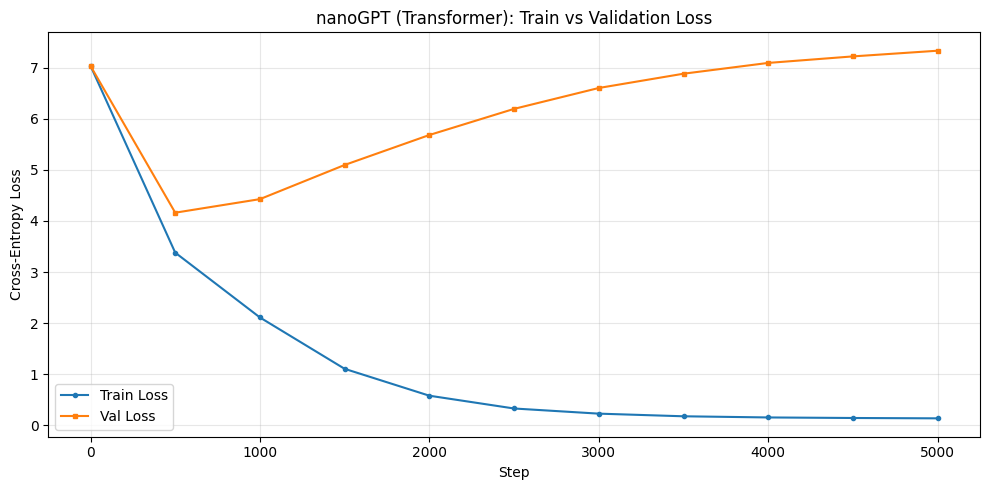

Final train loss: 0.1391
Final val loss:   7.3311
Gap (val - train): 7.1920


In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(eval_steps, train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(eval_steps, val_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('nanoGPT (Transformer): Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

gap = val_losses[-1] - train_losses[-1]
print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss:   {val_losses[-1]:.4f}")
print(f"Gap (val - train): {gap:.4f}")

#### Sample poems from the trained nanoGPT

In [38]:
def generate_text(prompt, max_new_tokens=1000, temperature=0.8, top_k=200):
    """Generate text from the nanoGPT model given a string prompt."""
    model.eval()
    tokens = encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE)[None, ...]
    with torch.no_grad():
        with ctx:
            y = model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    model.train()
    return decode(y[0].tolist())

#### Fine-tune nanoGPT on Shakespeare Sonnets

Load the best checkpoint from play-training, then fine-tune on the sonnets with a lower learning rate.

In [41]:
checkpoint = torch.load(BEST_GPT_PATH, map_location=DEVICE, weights_only=False)
print(f"Loaded best play-trained checkpoint — val loss {checkpoint['best_val_loss']:.4f} "
      f"(step {checkpoint['iter_num']})")

model = NanoGPT(config).to(DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f"Model: {model.get_num_params():,} parameters")

sonnet_encoded = np.array(encode(sonnet_text_raw), dtype=np.int64)
sn = len(sonnet_encoded)
sonnet_train = sonnet_encoded[:int(sn * 0.9)]
sonnet_val = sonnet_encoded[int(sn * 0.9):]
print(f"Sonnets: {len(sonnet_text_raw):,} chars -> {sn:,} BPE tokens ({len(sonnet_text_raw)/sn:.1f} chars/token)")
print(f"Train: {len(sonnet_train):,} | Val: {len(sonnet_val):,}")

Loaded best play-trained checkpoint — val loss 4.1623 (step 500)
Model: 11,113,344 parameters
Sonnets: 94,903 chars -> 33,473 BPE tokens (2.8 chars/token)
Train: 30,125 | Val: 3,348


In [42]:
ft_lr = 3e-4
ft_max_iters = 2000
ft_warmup = 100
ft_eval_interval = 200
ft_eval_iters = 100
ft_batch_size = 32

def ft_get_batch(split):
    data = sonnet_train if split == 'train' else sonnet_val
    ix = torch.randint(len(data) - block_size, (ft_batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].copy()) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].copy()) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

def ft_get_lr(it):
    if it < ft_warmup:
        return ft_lr * it / ft_warmup
    if it > ft_max_iters:
        return ft_lr * 0.1
    decay_ratio = (it - ft_warmup) / (ft_max_iters - ft_warmup)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return ft_lr * 0.1 + coeff * (ft_lr - ft_lr * 0.1)

@torch.no_grad()
def ft_estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(ft_eval_iters)
        for k in range(ft_eval_iters):
            X, Y = ft_get_batch(split)
            with ctx:
                _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

ft_optimizer = torch.optim.AdamW(model.parameters(), lr=ft_lr, weight_decay=0.1)

ft_train_losses, ft_val_losses, ft_steps = [], [], []
ft_best_val = 1e9

model.train()
t0 = time.time()

for it in range(ft_max_iters + 1):
    lr = ft_get_lr(it)
    for pg in ft_optimizer.param_groups:
        pg['lr'] = lr

    if it % ft_eval_interval == 0:
        losses = ft_estimate_loss()
        ft_train_losses.append(losses['train'])
        ft_val_losses.append(losses['val'])
        ft_steps.append(it)
        marker = ""
        if losses['val'] < ft_best_val:
            ft_best_val = losses['val']
            marker = " *"
        print(f"step {it:4d} | train {losses['train']:.4f} | val {losses['val']:.4f} | lr {lr:.2e}{marker}")

    X, Y = ft_get_batch('train')
    with ctx:
        _, loss = model(X, Y)

    scaler.scale(loss).backward()
    scaler.unscale_(ft_optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(ft_optimizer)
    scaler.update()
    ft_optimizer.zero_grad(set_to_none=True)
    t0 = time.time()

print(f"\nFine-tuning complete. Best val loss: {ft_best_val:.4f}")

step    0 | train 4.4541 | val 4.3933 | lr 0.00e+00 *
step  200 | train 1.8174 | val 4.5412 | lr 2.98e-04
step  400 | train 0.3313 | val 5.6067 | lr 2.84e-04
step  600 | train 0.1182 | val 6.4094 | lr 2.56e-04
step  800 | train 0.0816 | val 6.8423 | lr 2.19e-04
step 1000 | train 0.0673 | val 7.0555 | lr 1.76e-04
step 1200 | train 0.0596 | val 7.2641 | lr 1.32e-04
step 1400 | train 0.0553 | val 7.3402 | lr 9.12e-05
step 1600 | train 0.0518 | val 7.3857 | lr 5.85e-05
step 1800 | train 0.0497 | val 7.4240 | lr 3.73e-05
step 2000 | train 0.0490 | val 7.4698 | lr 3.00e-05

Fine-tuning complete. Best val loss: 4.3933


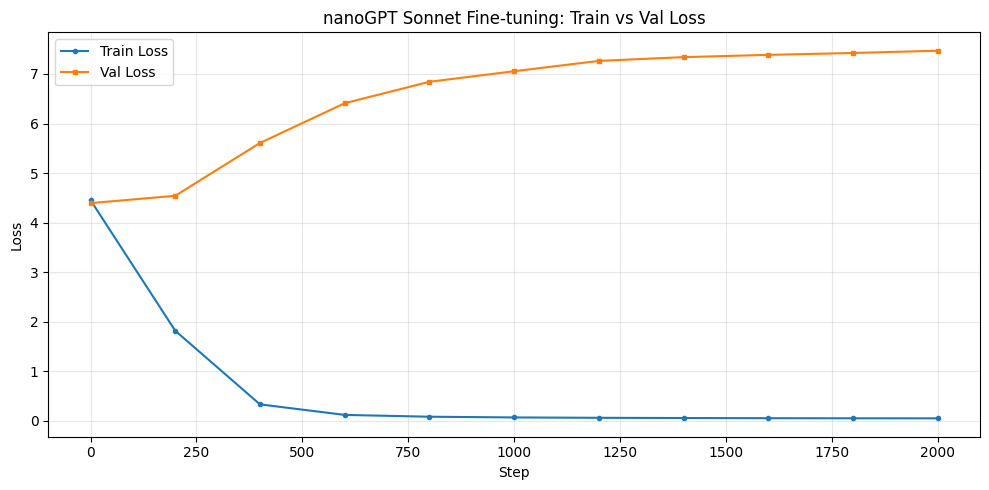

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(ft_steps, ft_train_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(ft_steps, ft_val_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('nanoGPT Sonnet Fine-tuning: Train vs Val Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Sample sonnets from finetuned nanoGPT

In [45]:
print(generate_text("@\nShall I compare thee to a summer's day?\n", max_new_tokens=500, temperature=0.8))

 ⁇  Shall I compare thee to a summer's day? Thou art more lovely and more temperate: Rough winds do shake the darling buds of May, And summer's lease hath all too short a date: Sometime too hot the eye of heaven shines, And often is his gold complexion dimmed, And every fair from fair sometime declines, By chance, or nature's changing course untrimmed: But thy eternal summer shall not fade, Nor lose possession of that fair thou ow'st, Nor shall death brag thou wand'rest in his shade, When in eternal lines to time thou grow'st, So long as men can breathe or eyes can see, So long lives this, and this gives life to thee.  ⁇  Devouring Time blunt thou the lion's paws, And make the earth devour her own sweet brood, Pluck the keen teeth from the fierce tiger's jaws, And burn the long-lived phoenix, in her blood, Make glad and sorry seasons as thou fleet'st, And do whate'er thou wilt swift-footed Time To the wide world and all her fading sweets: But I forbid thee one most heinous crime, O car

---
### 3. Pretrained nanoGPT.

We load [nishantup/nanogpt-slm-124m](https://huggingface.co/nishantup/nanogpt-slm-124m), a 124M-parameter model trained on 133 Classic English fiction novels. We fine-tune it further and sample poems.

In [13]:
torch.cuda.empty_cache()

In [14]:
import math
import time
from dataclasses import dataclass
from contextlib import nullcontext

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F

In [15]:
@dataclass
class GPTConfig:
    block_size: int = 256 
    vocab_size: int = 50257 
    n_layer: int = 12 
    n_head: int = 12 
    n_embd: int = 768
    dropout: float = 0.2
    bias: bool = False

In [16]:
class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                         .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                    dropout_p=self.dropout if self.training else 0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu = nn.GELU()
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte=nn.Embedding(config.vocab_size, config.n_embd),
            wpe=nn.Embedding(config.block_size, config.n_embd),
            drop=nn.Dropout(config.dropout),
            h=nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f=LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight

    def forward(self, idx, targets=None):
        B, T = idx.size()
        assert T <= self.config.block_size
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [17]:
from huggingface_hub import hf_hub_download
import torch

torch.cuda.empty_cache()

model_path = hf_hub_download(
    repo_id="nishantup/nanogpt-slm-124m",
    filename="nanogpt_slm_best.pth"
)

state_dict = torch.load(model_path)

In [18]:
config = GPTConfig()
model = GPT(config)

model.load_state_dict(state_dict, strict=False)

model = model.to(DEVICE)

print(f"Pretrained nanoGPT loaded: {sum(p.numel() for p in model.parameters()):,} parameters")
print(f"Config: block_size={config.block_size}, vocab_size={config.vocab_size}, "
      f"n_layer={config.n_layer}, n_head={config.n_head}, n_embd={config.n_embd}")

Pretrained nanoGPT loaded: 123,747,840 parameters
Config: block_size=256, vocab_size=50257, n_layer=12, n_head=12, n_embd=768


#### Fine-tune on Shakespeare

In [19]:
import tiktoken

enc = tiktoken.get_encoding("gpt2")
encode = lambda s: enc.encode(s, allowed_special=set())
decode = lambda l: enc.decode(l)
print(f"GPT-2 BPE vocab: {enc.n_vocab} tokens")
print(f"Sonnet text encodes to {len(encode(sonnet_text_raw)):,} tokens "
      f"(from {len(sonnet_text_raw):,} chars, ~{len(sonnet_text_raw)/len(encode(sonnet_text_raw)):.1f} chars/token)")

GPT-2 BPE vocab: 50257 tokens
Sonnet text encodes to 25,535 tokens (from 94,903 chars, ~3.7 chars/token)


In [20]:
block_size = 256
batch_size = 16
max_iters = 500
learning_rate = 1e-4
eval_interval = 50
eval_iters = 20
grad_clip = 1.0

In [21]:
ctx = torch.amp.autocast(device_type='cuda', dtype=ptdtype) if DEVICE_TYPE == 'cuda' else nullcontext()

data = np.array(encode(sonnet_text_raw), dtype=np.int64)
n = len(data)
train_data = data[:int(n * 0.9)]
val_data = data[int(n * 0.9):]
print(f"Fine-tune data (sonnets): {n:,} BPE tokens | train {len(train_data):,} | val {len(val_data):,}")

Fine-tune data (sonnets): 25,535 BPE tokens | train 22,981 | val 2,554


In [22]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i:i+block_size].copy()) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+1+block_size].copy()) for i in ix])
    return x.to(DEVICE), y.to(DEVICE)

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            with ctx:
                _, loss = model(x, y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

train_data_losses = []
val_data_losses = []
steps = []
best_val = 1e9

model.train()
t0 = time.time()

for it in range(max_iters + 1):
    if it % eval_interval == 0:
        losses = estimate_loss()
        train_data_losses.append(losses['train'])
        val_data_losses.append(losses['val'])
        steps.append(it)
        marker = " *" if losses['val'] < best_val else ""
        if losses['val'] < best_val:
            best_val = losses['val']
        print(f"step {it:4d} | train loss {losses['train']:.4f} | val loss {losses['val']:.4f}{marker}")

    x, y = get_batch('train')
    with ctx:
        _, loss = model(x, y)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    if DEVICE_TYPE == 'tpu':
        xm.optimizer_step(optimizer)
    else: 
        optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    t0 = time.time()

print(f"Fine-tuning complete. Best val loss: {best_val:.4f}")

step    0 | train loss 6.3417 | val loss 6.3293 *
step   50 | train loss 2.8135 | val loss 4.6799 *
step  100 | train loss 1.1934 | val loss 5.0355
step  150 | train loss 0.3841 | val loss 5.4437
step  200 | train loss 0.1451 | val loss 5.7416
step  250 | train loss 0.0756 | val loss 6.0720
step  300 | train loss 0.0572 | val loss 6.2910
step  350 | train loss 0.0483 | val loss 6.3886
step  400 | train loss 0.0476 | val loss 6.4886
step  450 | train loss 0.0426 | val loss 6.6433
step  500 | train loss 0.0403 | val loss 6.6559
Fine-tuning complete. Best val loss: 4.6799


#### Fine-tuning loss curve

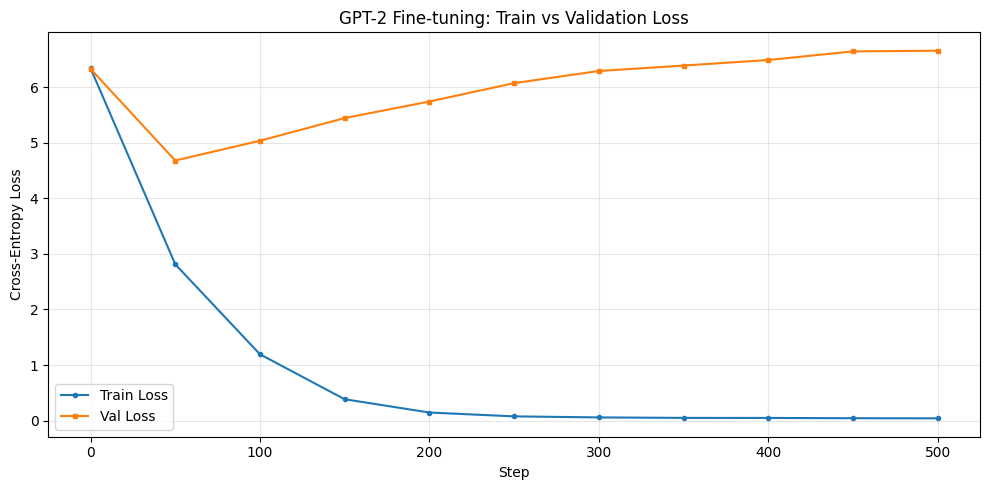

Final train loss: 0.0403
Final val loss:   6.6559


In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(steps, train_data_losses, label='Train Loss', marker='o', markersize=3)
plt.plot(steps, val_data_losses, label='Val Loss', marker='s', markersize=3)
plt.xlabel('Step')
plt.ylabel('Cross-Entropy Loss')
plt.title('GPT-2 Fine-tuning: Train vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_data_losses[-1]:.4f}")
print(f"Final val loss:   {val_data_losses[-1]:.4f}")

#### Sample poems.

In [25]:
def generate(prompt, max_new_tokens=500, temperature=0.8, top_k=50):
    model.eval()
    tokens = encode(prompt)
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE)[None, ...]
    with torch.no_grad():
        with ctx:
            y = model.generate(x, max_new_tokens, temperature=temperature, top_k=top_k)
    return decode(y[0].tolist())

In [27]:
print(generate("@\nShall I compare thee to a summer's day?\n", max_new_tokens=500, temperature=0.8, top_k=50))

@
Shall I compare thee to a summer's day?
Thou art more lovely and more temperate:
Rough winds do shake the darling buds of May,
And summer's lease hath all too short a date:
Sometime too hot the eye of heaven shines,
And often is his gold complexion dimmed,
And every fair from fair sometime declines,
By chance, or nature's changing course untrimmed:
But thy eternal summer shall not fade,
Nor lose possession of that fair thou ow'st,
Nor shall death brag thou wand'rest in his shade,
When in eternal lines to time thou grow'st,
  So long as men can breathe or eyes can see,
  So long lives this, and this gives life to thee.


@
Devouring Time blunt thou the lion's paws,
And make the earth devour her own sweet brood,
Pluck the keen teeth from the fierce tiger's jaws,
And burn the long-lived phoenix, in her blood,
Make glad and sorry seasons as thou fleet'st,
And do whate'er thou wilt swift-footed Time
To the wide world and all her fading sweets:
But I forbid thee one most heinous crime,
O c